In [5]:
# ════════════════════════════════════════════════
#  الخلية 1: تثبيت المكتبات والتحقق من البيئة
# ════════════════════════════════════════════════

# ⚠️ مهم: لا تعيد تثبيت torch إذا كان مثبت مع CUDA
# لأن هذا السطر قد يرجعك لنسخة CPU بدون GPU ❌
# !pip install torch torchvision --quiet   ← احذفه

# تثبيت باقي المكتبات فقط

import torch, pandas, numpy, sklearn

print(f"✅ PyTorch  : {torch.__version__}")
print(f"   CUDA     : {torch.version.cuda}")  # 🔥 إضافة مهمة
print(f"✅ Pandas   : {pandas.__version__}")
print(f"✅ Numpy    : {numpy.__version__}")
print(f"✅ Sklearn  : {sklearn.__version__}")

# التحقق من GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🖥️  Device  : {device}")

if device.type == "cuda":
    print(f"   GPU     : {torch.cuda.get_device_name(0)}")
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"   Memory  : {mem:.1f} GB")
else:
    print("⚠️ GPU غير مستخدم - تحقق من الإعدادات")

✅ PyTorch  : 2.7.1+cu118
   CUDA     : 11.8
✅ Pandas   : 2.3.3
✅ Numpy    : 2.2.6
✅ Sklearn  : 1.7.2

🖥️  Device  : cuda
   GPU     : NVIDIA RTX 4000 Ada Generation
   Memory  : 21.5 GB


In [6]:
import os

DATA_PATH = r"C:\Users\user\Pdishing_Detection\phishing_dataset_final.CSV"

assert os.path.exists(DATA_PATH), f"❌ الملف غير موجود:\n{DATA_PATH}"

print(f"✅ DATA_PATH OK:\n{DATA_PATH}")

✅ DATA_PATH OK:
C:\Users\user\Pdishing_Detection\phishing_dataset_final.CSV


In [7]:
# ════════════════════════════════════════════════
#  الخلية 1: تثبيت المكتبات والتحقق من البيئة
# ════════════════════════════════════════════════

# ⚠️ مهم: لا تعيد تثبيت torch إذا كان مثبت مع CUDA
# لأن هذا السطر قد يرجعك لنسخة CPU بدون GPU ❌
# !pip install torch torchvision --quiet   ← احذفه

# تثبيت باقي المكتبات فقط

import torch, pandas, numpy, sklearn

print(f"✅ PyTorch  : {torch.__version__}")
print(f"   CUDA     : {torch.version.cuda}")  # 🔥 إضافة مهمة
print(f"✅ Pandas   : {pandas.__version__}")
print(f"✅ Numpy    : {numpy.__version__}")
print(f"✅ Sklearn  : {sklearn.__version__}")

# التحقق من GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🖥️  Device  : {device}")

if device.type == "cuda":
    print(f"   GPU     : {torch.cuda.get_device_name(0)}")
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"   Memory  : {mem:.1f} GB")
else:
    print("⚠️ GPU غير مستخدم - تحقق من الإعدادات")

✅ PyTorch  : 2.7.1+cu118
   CUDA     : 11.8
✅ Pandas   : 2.3.3
✅ Numpy    : 2.2.6
✅ Sklearn  : 1.7.2

🖥️  Device  : cuda
   GPU     : NVIDIA RTX 4000 Ada Generation
   Memory  : 21.5 GB


In [8]:
# ════════════════════════════════════════════════
#  تحديد مسار البيانات (Local فقط)
# ════════════════════════════════════════════════

import os

# ⚠️ تأكد من الاسم الصحيح للمجلد
DATA_PATH = r"C:\Users\user\Pdishing_Detection\phishing_dataset_final.CSV"
# التحقق من وجود الملف
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"❌ الملف غير موجود:\n{DATA_PATH}")

print(f"✅ تم العثور على البيانات في:\n{DATA_PATH}")

✅ تم العثور على البيانات في:
C:\Users\user\Pdishing_Detection\phishing_dataset_final.CSV


In [9]:
print("CUDA Available:", torch.cuda.is_available())

CUDA Available: True


In [10]:
import os

# التحقق من وجود الملف أولاً
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"❌ الملف غير موجود:\n{DATA_PATH}")

# حساب الحجم
size_mb = os.path.getsize(DATA_PATH) / 1e6

print(f"\n✅ File found: {DATA_PATH}")
print(f"   Size: {size_mb:.1f} MB")

# 🔥 إضافة مهمة: تقييم حجم البيانات
if size_mb > 500:
    print("⚠️ Dataset كبير - يفضل استخدام batch loading أثناء التدريب")
elif size_mb > 100:
    print("ℹ️ Dataset متوسط - مناسب للـ GPU")
else:
    print("ℹ️ Dataset صغير - التدريب سيكون سريع")


✅ File found: C:\Users\user\Pdishing_Detection\phishing_dataset_final.CSV
   Size: 84.6 MB
ℹ️ Dataset صغير - التدريب سيكون سريع


In [11]:
import pandas as pd

# قراءة عينة من البيانات
try:
    df_preview = pd.read_csv(DATA_PATH, nrows=12)
except Exception as e:
    raise RuntimeError(f"❌ خطأ أثناء قراءة الملف:\n{e}")

print("\n📊 Data Preview:")
print(df_preview)

# عرض أسماء الأعمدة
print("\n🧾 Columns:")
print(list(df_preview.columns))

# 🔥 إضافة مهمة: معلومات عامة عن البيانات
print("\nℹ️ Data Info:")
print(f"Number of columns: {df_preview.shape[1]}")
print(f"Sample rows loaded: {df_preview.shape[0]}")

# 🔥 التحقق من وجود قيم مفقودة في العينة
print("\n⚠️ Missing values (sample):")
print(df_preview.isnull().sum())


📊 Data Preview:
                                                  url  label
0                               inside-commercial.com      0
1                                       buspronet.net      0
2                                  les-coccinelles.fr      0
3                                         1057.casino      0
4                                strapi.scentbird.com      0
5                               patriotnewsalerts.com      0
6       acs-lazada-sg.m.taobao.com.gds.alibabadns.com      0
7                                            bj21.com      0
8                                         gemfame.com      0
9                              1024teradownloader.com      0
10  https://tech.chickletsinthekitchen.com/wp-cont...      1
11                                  ivpn-dc.apple.com      0

🧾 Columns:
['url', 'label']

ℹ️ Data Info:
Number of columns: 2
Sample rows loaded: 12

⚠️ Missing values (sample):
url      0
label    0
dtype: int64


In [12]:
# ════════════════════════════════════════════════
#  الخلية 3: الإعدادات العامة (Config)
# ════════════════════════════════════════════════
import os
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MAX_URL_LEN  = 200
EMBED_DIM    = 64
CNN_FILTERS  = 128
CNN_KERNELS  = [2, 3, 4, 5]
LSTM_HIDDEN  = 128
LSTM_LAYERS  = 2
DROPOUT      = 0.3
FC_HIDDEN    = 128

BATCH_SIZE    = 512
EPOCHS        = 10
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4
PATIENCE      = 3

TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10
TEST_RATIO  = 0.10

MAX_SAMPLES = None

NUM_WORKERS = 0   # على ويندوز داخل Jupyter هذا أكثر أمانًا
PIN_MEMORY  = torch.cuda.is_available()

print("✅ Config loaded")
print(f"Device: {DEVICE}")
print(f"EPOCHS: {EPOCHS}")
print(f"BATCH_SIZE: {BATCH_SIZE}")

✅ Config loaded
Device: cuda
EPOCHS: 10
BATCH_SIZE: 512


In [13]:
from collections import Counter

SPECIAL_TOKENS = {"<PAD>": 0, "<UNK>": 1}

def build_vocab(urls, max_chars=200, min_freq=1):
    counter = Counter()

    for url in urls:
        if not isinstance(url, str):
            continue
        counter.update(url[:max_chars])

    vocab = dict(SPECIAL_TOKENS)

    for char, freq in counter.most_common():
        if freq < min_freq:
            continue
        if char not in vocab:
            vocab[char] = len(vocab)

    return vocab

def url_to_indices(url, vocab, max_len):
    unk = vocab["<UNK>"]
    pad = vocab["<PAD>"]

    if not isinstance(url, str):
        url = ""

    indices = [vocab.get(c, unk) for c in url[:max_len]]

    if len(indices) < max_len:
        indices += [pad] * (max_len - len(indices))
    else:
        indices = indices[:max_len]

    return indices

In [14]:
import torch
from torch.utils.data import Dataset, DataLoader

class URLDataset(Dataset):
    def __init__(self, urls, labels, vocab, max_len):
        self.urls = list(urls)
        self.labels = list(labels)
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = torch.tensor(
            url_to_indices(self.urls[idx], self.vocab, self.max_len),
            dtype=torch.long
        )
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

def create_dataloaders(urls_train, labs_train, urls_val, labs_val,
                       urls_test, labs_test, vocab):

    train_ds = URLDataset(urls_train, labs_train, vocab, MAX_URL_LEN)
    val_ds   = URLDataset(urls_val,   labs_val,   vocab, MAX_URL_LEN)
    test_ds  = URLDataset(urls_test,  labs_test,  vocab, MAX_URL_LEN)

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY
    )

    return train_loader, val_loader, test_loader

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F

EMBED_DIM     = 64
CNN_FILTERS   = 128
CNN_KERNELS   = [2, 3, 4, 5]
LSTM_HIDDEN   = 128
LSTM_LAYERS   = 2
FC_HIDDEN     = 128
DROPOUT       = 0.3

class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_out: torch.Tensor):
        scores  = self.attn(lstm_out).squeeze(-1)
        weights = F.softmax(scores, dim=1)
        context = torch.bmm(weights.unsqueeze(1), lstm_out).squeeze(1)
        return context, weights


class PhishingDetector(nn.Module):

    def __init__(self, vocab_size, embed_dim=EMBED_DIM, cnn_filters=CNN_FILTERS,
                 cnn_kernels=CNN_KERNELS, lstm_hidden=LSTM_HIDDEN,
                 lstm_layers=LSTM_LAYERS, fc_hidden=FC_HIDDEN,
                 dropout=DROPOUT, num_classes=2):
        super().__init__()

        # ── Embedding ─────────────────────────
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # 🔥 تحسين: dropout بعد embedding (مهم)
        self.embed_dropout = nn.Dropout(dropout * 0.5)

        # ── CNN ──────────────────────────────
        self.conv_layers = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(embed_dim, cnn_filters, kernel_size=k, padding='same'),
                nn.BatchNorm1d(cnn_filters),
                nn.ReLU(),
            )
            for k in cnn_kernels
        ])

        total_cnn = cnn_filters * len(cnn_kernels)

        # ── Projection ───────────────────────
        self.cnn_proj = nn.Sequential(
            nn.Linear(total_cnn, lstm_hidden),
            nn.LayerNorm(lstm_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # ── BiLSTM ──────────────────────────
        self.bilstm = nn.LSTM(
            input_size    = lstm_hidden,
            hidden_size   = lstm_hidden,
            num_layers    = lstm_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = dropout if lstm_layers > 1 else 0.0,
        )

        # ── Attention ───────────────────────
        self.attention = AttentionLayer(lstm_hidden * 2)

        # ── Classifier ──────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2, fc_hidden),
            nn.LayerNorm(fc_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(fc_hidden, fc_hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout / 2),

            nn.Linear(fc_hidden // 2, num_classes),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')

    def forward(self, x):

        # ── Embedding ───────────────────────
        x_emb = self.embedding(x)
        x_emb = self.embed_dropout(x_emb)  # 🔥 تحسين مهم

        # ── CNN ────────────────────────────
        x_cnn = x_emb.permute(0, 2, 1)
        outs  = [conv(x_cnn) for conv in self.conv_layers]
        x_cat = torch.cat(outs, dim=1)

        # 🔥 تحسين: منع قيم متطرفة (stability)
        x_cat = torch.clamp(x_cat, -10, 10)

        x_cat = x_cat.permute(0, 2, 1)

        # ── Projection ─────────────────────
        x_proj = self.cnn_proj(x_cat)

        # ── LSTM ──────────────────────────
        lstm_out, _ = self.bilstm(x_proj)

        # ── Attention ─────────────────────
        ctx, attn_w = self.attention(lstm_out)

        # ── Classification ────────────────
        logits = self.classifier(ctx)

        return logits, attn_w

print("✅ PhishingDetector architecture defined")

✅ PhishingDetector architecture defined


In [16]:
# ════════════════════════════════════════════════
#  تحديد المسار + الإعدادات الأساسية
# ════════════════════════════════════════════════

import os

# 🔹 مسار البيانات (عدله إذا اختلف)
DATA_PATH = r"C:\Users\user\Pdishing_Detection\phishing_dataset_final.csv"

# 🔹 تحقق من الملف
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"❌ الملف غير موجود:\n{DATA_PATH}")

print(f"✅ DATA_PATH OK:\n{DATA_PATH}")

# ──────────────────────────────────────────────
# إعدادات عامة (مهمة لتجنب الأخطاء القادمة)
# ──────────────────────────────────────────────

SEED = 42

MAX_SAMPLES = None   # للتجارب: 200_000

TRAIN_RATIO = 0.8
VAL_RATIO   = 0.1
TEST_RATIO  = 0.1

MAX_URL_LEN = 200
BATCH_SIZE  = 64

print("✅ All configs ready")

✅ DATA_PATH OK:
C:\Users\user\Pdishing_Detection\phishing_dataset_final.csv
✅ All configs ready


In [17]:
# ════════════════════════════════════════════════
#  بناء القاموس (Vocabulary)
# ════════════════════════════════════════════════

from collections import Counter

def build_vocab(urls, max_chars=200, min_freq=1):
    """
    بناء قاموس الأحرف من بيانات التدريب فقط
    """
    counter = Counter()

    for url in urls:
        url = str(url)[:max_chars]
        counter.update(url)

    # فقط الأحرف التي تكررت أكثر من min_freq
    chars = [c for c, f in counter.items() if f >= min_freq]

    # 0 = padding
    vocab = {"<PAD>": 0}

    for i, c in enumerate(sorted(chars), start=1):
        vocab[c] = i

    return vocab

In [18]:
# ════════════════════════════════════════════════
#  تحميل البيانات + تنظيف + تقسيم + DataLoader (نسخة احترافية)
# ════════════════════════════════════════════════

import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

# ──────────────────────────────────────────────
# 1. تحميل البيانات
# ──────────────────────────────────────────────
print("📥 Loading dataset...")
df = pd.read_csv(DATA_PATH)

df["url"] = df["url"].astype(str).str.strip()
df["label"] = pd.to_numeric(df["label"], errors="coerce")

df = df.dropna(subset=["url", "label"]).copy()
df["label"] = df["label"].astype(int)
df = df[df["label"].isin([0, 1])].reset_index(drop=True)
df = df[df["url"].str.len() > 0].reset_index(drop=True)

# ── اختيار عينة (للتجارب فقط) ───────────────
if MAX_SAMPLES is not None and len(df) > MAX_SAMPLES:
    df = df.sample(MAX_SAMPLES, random_state=SEED).reset_index(drop=True)

print(f"Total: {len(df):,}")

# ──────────────────────────────────────────────
# 2. حفظ نسخة كاملة للـ multi-seed
# ──────────────────────────────────────────────
full_df = df.copy()
print(f"✅ full_df ready — {len(full_df):,} rows")

# ──────────────────────────────────────────────
# 3. التقسيم
# ──────────────────────────────────────────────
urls = df["url"].tolist()
labels = df["label"].tolist()

urls_tv, urls_test, labs_tv, labs_test = train_test_split(
    urls, labels,
    test_size=TEST_RATIO,
    random_state=SEED,
    stratify=labels
)

val_r = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)

urls_train, urls_val, labs_train, labs_val = train_test_split(
    urls_tv, labs_tv,
    test_size=val_r,
    random_state=SEED,
    stratify=labs_tv
)

print(f"Train: {len(urls_train):,}")
print(f"Val  : {len(urls_val):,}")
print(f"Test : {len(urls_test):,}")

# ──────────────────────────────────────────────
# 4. بناء القاموس
# ──────────────────────────────────────────────
print("🔤 Building vocabulary...")
vocab = build_vocab(urls_train, max_chars=MAX_URL_LEN, min_freq=1)
print(f"Vocab size: {len(vocab):,}")

# ──────────────────────────────────────────────
# 5. Dataset (Lazy Loading 🔥)
# ──────────────────────────────────────────────
class URLDataset(Dataset):
    def __init__(self, urls, labels, vocab, max_len):
        self.urls = urls
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def encode(self, url):
        url = url[:self.max_len]
        encoded = [self.vocab.get(c, 0) for c in url]
        encoded += [0] * (self.max_len - len(encoded))
        return encoded

    def __len__(self):
        return len(self.urls)

    def __getitem__(self, idx):
        x = torch.tensor(self.encode(self.urls[idx]), dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

# ──────────────────────────────────────────────
# 6. DataLoader (محسّن للـ Windows + GPU)
# ──────────────────────────────────────────────
print("⚙️ Creating DataLoaders...")

train_ds = URLDataset(urls_train, labs_train, vocab, MAX_URL_LEN)
val_ds   = URLDataset(urls_val,   labs_val,   vocab, MAX_URL_LEN)
test_ds  = URLDataset(urls_test,  labs_test,  vocab, MAX_URL_LEN)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,     # مهم جدًا على Windows
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("✅ DataLoaders ready")
print(f"Train batches: {len(train_loader):,}")
print(f"Val batches  : {len(val_loader):,}")
print(f"Test batches : {len(test_loader):,}")

📥 Loading dataset...
Total: 2,416,245
✅ full_df ready — 2,416,245 rows
Train: 1,932,995
Val  : 241,625
Test : 241,625
🔤 Building vocabulary...
Vocab size: 420
⚙️ Creating DataLoaders...
✅ DataLoaders ready
Train batches: 30,204
Val batches  : 3,776
Test batches : 3,776


In [19]:
# ════════════════════════════════════════════════
#  create_dataloaders (نسخة احترافية Lazy + GPU + Windows)
# ════════════════════════════════════════════════

import torch
from torch.utils.data import Dataset, DataLoader

class URLDataset(Dataset):
    def __init__(self, urls, labels, vocab, max_len):
        self.urls = urls
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def encode(self, url):
        url = url[:self.max_len]
        encoded = [self.vocab.get(c, 0) for c in url]
        encoded += [0] * (self.max_len - len(encoded))
        return encoded

    def __len__(self):
        return len(self.urls)

    def __getitem__(self, idx):
        x = torch.tensor(self.encode(self.urls[idx]), dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y


def create_dataloaders(
    urls_train, labs_train,
    urls_val, labs_val,
    urls_test, labs_test,
    vocab,
    batch_size=BATCH_SIZE,
    max_len=MAX_URL_LEN
):

    train_ds = URLDataset(urls_train, labs_train, vocab, max_len)
    val_ds   = URLDataset(urls_val,   labs_val,   vocab, max_len)
    test_ds  = URLDataset(urls_test,  labs_test,  vocab, max_len)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,   # مهم جدًا على Windows
        pin_memory=True
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    return train_loader, val_loader, test_loader

In [20]:
# ════════════════════════════════════════════════
#  الخلية 8: تحميل البيانات والتقسيم وبناء Vocab
# ════════════════════════════════════════════════
import pandas as pd
from sklearn.model_selection import train_test_split

print("📥 Loading dataset...")
df = pd.read_csv(DATA_PATH)

# ── تنظيف الأعمدة الأساسية ───────────────────
df["url"] = df["url"].astype(str).str.strip()
df["label"] = pd.to_numeric(df["label"], errors="coerce")

# إزالة الصفوف غير الصالحة
df = df.dropna(subset=["url", "label"]).copy()
df["label"] = df["label"].astype(int)
df = df[df["label"].isin([0, 1])].reset_index(drop=True)

# حذف URLs الفارغة
df = df[df["url"].str.len() > 0].reset_index(drop=True)

# ── للاختبار السريع: خذ عينة ──────────────────
if MAX_SAMPLES is not None and len(df) > MAX_SAMPLES:
    df = df.sample(MAX_SAMPLES, random_state=SEED).reset_index(drop=True)
    print(f"   ⚡ Subsampled to {MAX_SAMPLES:,} rows")

print(f"   Total  : {len(df):,}")
print(f"   Legit  : {(df['label'] == 0).sum():,} ({(df['label'] == 0).mean() * 100:.2f}%)")
print(f"   Phish  : {(df['label'] == 1).sum():,} ({(df['label'] == 1).mean() * 100:.2f}%)")

# ── تقسيم 80/10/10 مع stratify ────────────────
urls = df["url"].tolist()
labels = df["label"].tolist()

urls_tv, urls_test, labs_tv, labs_test = train_test_split(
    urls,
    labels,
    test_size=TEST_RATIO,
    random_state=SEED,
    stratify=labels
)

val_r = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)

urls_train, urls_val, labs_train, labs_val = train_test_split(
    urls_tv,
    labs_tv,
    test_size=val_r,
    random_state=SEED,
    stratify=labs_tv
)

print(f"\n✂️ Split:")
print(f"   Train : {len(urls_train):,}")
print(f"   Val   : {len(urls_val):,}")
print(f"   Test  : {len(urls_test):,}")

# ── بناء القاموس على بيانات التدريب فقط ────────
print("\n🔤 Building vocabulary from training set only...")
vocab = build_vocab(urls_train, max_chars=MAX_URL_LEN, min_freq=1)
print(f"   Vocab size: {len(vocab):,}")

# ── إنشاء DataLoaders ─────────────────────────
print("\n⚙️ Creating DataLoaders...")
train_loader, val_loader, test_loader = create_dataloaders(
    urls_train, labs_train,
    urls_val, labs_val,
    urls_test, labs_test,
    vocab
)

print(f"   Train batches: {len(train_loader):,}")
print(f"   Val batches  : {len(val_loader):,}")
print(f"   Test batches : {len(test_loader):,}")

📥 Loading dataset...
   Total  : 2,416,245
   Legit  : 2,132,847 (88.27%)
   Phish  : 283,398 (11.73%)

✂️ Split:
   Train : 1,932,995
   Val   : 241,625
   Test  : 241,625

🔤 Building vocabulary from training set only...
   Vocab size: 420

⚙️ Creating DataLoaders...
   Train batches: 30,204
   Val batches  : 3,776
   Test batches : 3,776


In [21]:
# ════════════════════════════════════════════════
#  إعداد الجهاز (GPU / CPU)
# ════════════════════════════════════════════════

import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"🖥️ Using device: {DEVICE}")

if DEVICE.type == "cuda":
    print(f"🚀 GPU: {torch.cuda.get_device_name(0)}")
    print(f"🔥 CUDA: {torch.version.cuda}")
else:
    print("⚠️ Running on CPU")

🖥️ Using device: cuda
🚀 GPU: NVIDIA RTX 4000 Ada Generation
🔥 CUDA: 11.8


In [22]:
CNN_KERNELS = [3, 5, 7]
print("✅ CNN_KERNELS =", CNN_KERNELS)

✅ CNN_KERNELS = [3, 5, 7]


In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_out: torch.Tensor):
        scores = self.attn(lstm_out).squeeze(-1)      # (B, L)
        weights = F.softmax(scores, dim=1)            # (B, L)
        context = torch.bmm(weights.unsqueeze(1), lstm_out).squeeze(1)
        return context, weights


class PhishingDetector(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int = EMBED_DIM,
        cnn_filters: int = CNN_FILTERS,
        cnn_kernels: list = CNN_KERNELS,
        lstm_hidden: int = LSTM_HIDDEN,
        lstm_layers: int = LSTM_LAYERS,
        fc_hidden: int = FC_HIDDEN,
        dropout: float = DROPOUT,
        num_classes: int = 2
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=0
        )

        # مهم: kernels فردية فقط
        assert all(k % 2 == 1 for k in cnn_kernels), \
            f"All CNN kernels must be odd, got: {cnn_kernels}"

        self.conv_layers = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(
                    in_channels=embed_dim,
                    out_channels=cnn_filters,
                    kernel_size=k,
                    padding=k // 2
                ),
                nn.BatchNorm1d(cnn_filters),
                nn.ReLU()
            )
            for k in cnn_kernels
        ])

        total_cnn = cnn_filters * len(cnn_kernels)

        self.cnn_proj = nn.Sequential(
            nn.Linear(total_cnn, lstm_hidden),
            nn.LayerNorm(lstm_hidden),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.bilstm = nn.LSTM(
            input_size=lstm_hidden,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0
        )

        self.attention = AttentionLayer(lstm_hidden * 2)

        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2, fc_hidden),
            nn.LayerNorm(fc_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(fc_hidden, fc_hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout / 2),

            nn.Linear(fc_hidden // 2, num_classes)
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor):
        x_emb = self.embedding(x)              # (B, L, E)
        x_cnn = x_emb.permute(0, 2, 1)         # (B, E, L)

        conv_outs = [conv(x_cnn) for conv in self.conv_layers]

        # حماية إضافية: توحيد الطول لو حصل أي اختلاف
        min_len = min(out.size(-1) for out in conv_outs)
        conv_outs = [out[:, :, :min_len] for out in conv_outs]

        x_cat = torch.cat(conv_outs, dim=1)    # (B, total_cnn, L)

        x_cat = x_cat.permute(0, 2, 1)         # (B, L, total_cnn)
        x_proj = self.cnn_proj(x_cat)          # (B, L, lstm_hidden)

        lstm_out, _ = self.bilstm(x_proj)      # (B, L, 2*lstm_hidden)

        context, attn_weights = self.attention(lstm_out)
        logits = self.classifier(context)

        return logits, attn_weights

print("✅ PhishingDetector redefined correctly")

✅ PhishingDetector redefined correctly


In [24]:
import torch
import torch.nn as nn

print(f"🚀 Using device: {DEVICE}")

model = PhishingDetector(vocab_size=len(vocab)).to(DEVICE)

if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"🧠 Model: CNN + BiLSTM + Attention")
print(f"   Total parameters    : {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")

n_legit = labs_train.count(0)
n_phish = labs_train.count(1)

eps = 1e-8
w_legit = len(labs_train) / (2.0 * (n_legit + eps))
w_phish = len(labs_train) / (2.0 * (n_phish + eps))

class_weights = torch.tensor([w_legit, w_phish], dtype=torch.float32).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-5
)

scaler = torch.amp.GradScaler("cuda") if DEVICE.type == "cuda" else None

print("✅ Model reinitialized")

🚀 Using device: cuda
🧠 Model: CNN + BiLSTM + Attention
   Total parameters    : 901,699
   Trainable parameters: 901,699
✅ Model reinitialized


In [25]:
# ════════════════════════════════════════════════
#  Hyperparameters (إعدادات التدريب)
# ════════════════════════════════════════════════

# 🔹 التدريب
EPOCHS = 10
BATCH_SIZE = 64

# 🔹 optimizer
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4

# 🔹 model
EMBED_DIM     = 64
CNN_FILTERS   = 128
cnn_kernels=[3, 5, 7]
LSTM_HIDDEN   = 128
LSTM_LAYERS   = 2
FC_HIDDEN     = 128
DROPOUT       = 0.3

print("✅ Hyperparameters ready")

✅ Hyperparameters ready


In [26]:
# ════════════════════════════════════════════════
#  الخلية 9: تهيئة النموذج والمحسّن والخسارة
# ════════════════════════════════════════════════

import torch
import torch.nn as nn

# ⚠️ لا تعيد تعريف DEVICE إذا كان معرف مسبقًا في Config
# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"🚀 Using device: {DEVICE}")

# ── إنشاء النموذج ────────────────────────────
model = PhishingDetector(vocab_size=len(vocab)).to(DEVICE)

# 🔥 تحسين: تفعيل cudnn benchmark للأداء (مع GPU)
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True

# إحصاءات النموذج
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"🧠 Model: CNN + BiLSTM + Attention")
print(f"   Total parameters    : {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")

# ── معالجة عدم التوازن (Imbalanced Classes) ───
n_legit = labs_train.count(0)
n_phish = labs_train.count(1)

# 🔥 حماية من القسمة على صفر
eps = 1e-8
w_legit = len(labs_train) / (2.0 * (n_legit + eps))
w_phish = len(labs_train) / (2.0 * (n_phish + eps))

class_weights = torch.tensor([w_legit, w_phish], dtype=torch.float32).to(DEVICE)

print(f"\n⚖️ Class weights (imbalance correction):")
print(f"   Legit  weight: {w_legit:.3f}")
print(f"   Phish  weight: {w_phish:.3f}  (×{w_phish/w_legit:.1f} higher)")

# 🔥 CrossEntropy مع weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

# ── المحسّن: AdamW ────────────────────────────
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

# ── Scheduler ────────────────────────────────
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-5
)

# ── Mixed Precision ──────────────────────────
if DEVICE.type == "cuda":
    scaler = torch.amp.GradScaler()
else:
    scaler = None

print(f"\n✅ Optimizer : AdamW (lr={LEARNING_RATE}, wd={WEIGHT_DECAY})")
print(f"   Scheduler : CosineAnnealing (T_max={EPOCHS})")
print(f"   Mixed Prec: {'ON (GPU)' if scaler else 'OFF (CPU)'}")

🚀 Using device: cuda
🧠 Model: CNN + BiLSTM + Attention
   Total parameters    : 901,699
   Trainable parameters: 901,699

⚖️ Class weights (imbalance correction):
   Legit  weight: 0.566
   Phish  weight: 4.263  (×7.5 higher)

✅ Optimizer : AdamW (lr=0.001, wd=0.0001)
   Scheduler : CosineAnnealing (T_max=10)
   Mixed Prec: ON (GPU)


In [27]:
# ════════════════════════════════════════════════
#  دوال التدريب والتقييم
# ════════════════════════════════════════════════
import numpy as np
import torch
from sklearn.metrics import f1_score, roc_auc_score

def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        if scaler is not None and device.type == "cuda":
            with torch.amp.autocast("cuda"):
                logits, _ = model(batch_x)
                loss = criterion(logits, batch_y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits, _ = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()

        preds = logits.argmax(dim=1)

        correct += (preds == batch_y).sum().item()
        total += batch_y.size(0)
        total_loss += loss.item() * batch_y.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

    return {
        "loss": total_loss / total,
        "acc": correct / total,
        "f1": f1_score(all_labels, all_preds)
    }


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []
    all_probs = []

    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        logits, _ = model(batch_x)
        loss = criterion(logits, batch_y)

        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = logits.argmax(dim=1)

        correct += (preds == batch_y).sum().item()
        total += batch_y.size(0)
        total_loss += loss.item() * batch_y.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    return {
        "loss": total_loss / total,
        "acc": correct / total,
        "f1": f1_score(all_labels, all_preds),
        "auc": roc_auc_score(all_labels, all_probs),
        "preds": np.array(all_preds),
        "labels": np.array(all_labels),
        "probs": np.array(all_probs),
    }

print("✅ Training functions loaded")

✅ Training functions loaded


In [28]:
print(hasattr(model, "embedding"))
print(model)

True
PhishingDetector(
  (embedding): Embedding(420, 64, padding_idx=0)
  (conv_layers): ModuleList(
    (0): Sequential(
      (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (1): Sequential(
      (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (2): Sequential(
      (0): Conv1d(64, 128, kernel_size=(7,), stride=(1,), padding=(3,))
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
  )
  (cnn_proj): Sequential(
    (0): Linear(in_features=384, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (bilstm): LSTM(128, 128, num_layers=2, batch_first=True,

In [29]:
# ════════════════════════════════════════════════
#  الخلية 10: Training Loop الرئيسية
# ════════════════════════════════════════════════
import time
import torch

history = {
    "train_loss": [], "train_acc": [], "train_f1": [],
    "val_loss":   [], "val_acc":   [], "val_f1": [], "val_auc": []
}

best_val_loss   = float("inf")
patience_count  = 0
best_model_path = "best_phishing_model.pt"

print(f"🚀 Training starts — {EPOCHS} epochs max\n")
print(f"{'Ep':>3} | {'Train L':>8} | {'Train A':>8} | {'Train F1':>8} | {'Val L':>8} | {'Val A':>8} | {'Val F1':>8} | {'Val AUC':>8} | {'LR':>8} | {'Time':>6}")
print("─" * 110)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # ── تدريب ──────────────────────────────────
    train_m = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, scaler)

    # ── تقييم ──────────────────────────────────
    val_m = evaluate(model, val_loader, criterion, DEVICE)

    scheduler.step()

    history["train_loss"].append(train_m["loss"])
    history["train_acc"].append(train_m["acc"])
    history["train_f1"].append(train_m["f1"])

    history["val_loss"].append(val_m["loss"])
    history["val_acc"].append(val_m["acc"])
    history["val_f1"].append(val_m["f1"])
    history["val_auc"].append(val_m["auc"])

    lr  = optimizer.param_groups[0]['lr']
    dur = time.time() - t0

    print(
        f"{epoch:>3} | "
        f"{train_m['loss']:>8.4f} | {train_m['acc']:>8.4f} | {train_m['f1']:>8.4f} | "
        f"{val_m['loss']:>8.4f} | {val_m['acc']:>8.4f} | {val_m['f1']:>8.4f} | {val_m['auc']:>8.4f} | "
        f"{lr:>8.2e} | {dur:>5.0f}s"
    )

    # ── Early Stopping ─────────────────────────
    if val_m["loss"] < best_val_loss:
        best_val_loss = val_m["loss"]
        patience_count = 0

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "val_loss": val_m["loss"],
            "val_f1": val_m["f1"],
            "val_auc": val_m["auc"],
            "vocab": vocab,
        }, best_model_path)

        print(f"    ↳ ✅ Best model saved (epoch {epoch})")

    else:
        patience_count += 1
        print(f"    ↳ No improvement ({patience_count}/{PATIENCE})")

        if patience_count >= PATIENCE:
            print(f"\n⏹️ Early stopping at epoch {epoch}")
            break

print("\n✅ Training complete!")
print(f"📁 Saved model: {best_model_path}")

🚀 Training starts — 10 epochs max

 Ep |  Train L |  Train A | Train F1 |    Val L |    Val A |   Val F1 |  Val AUC |       LR |   Time
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  1 |   0.0802 |   0.9633 |   0.8622 |   0.0471 |   0.9808 |   0.9232 |   0.9986 | 9.76e-04 |   794s
    ↳ ✅ Best model saved (epoch 1)
  2 |   0.0455 |   0.9813 |   0.9252 |   0.0405 |   0.9809 |   0.9239 |   0.9990 | 9.05e-04 |   798s
    ↳ ✅ Best model saved (epoch 2)
  3 |   0.0386 |   0.9843 |   0.9367 |   0.0378 |   0.9849 |   0.9388 |   0.9992 | 7.96e-04 |   786s
    ↳ ✅ Best model saved (epoch 3)
  4 |   0.0345 |   0.9865 |   0.9449 |   0.0387 |   0.9805 |   0.9227 |   0.9992 | 6.58e-04 |   787s
    ↳ No improvement (1/3)
  5 |   0.0308 |   0.9880 |   0.9508 |   0.0316 |   0.9882 |   0.9514 |   0.9994 | 5.05e-04 |   783s
    ↳ ✅ Best model saved (epoch 5)
  6 |   0.0275 |   0.9894 |   0.9564 |   0.0300 |   0.9873 |   0.9483 |   0.9994 

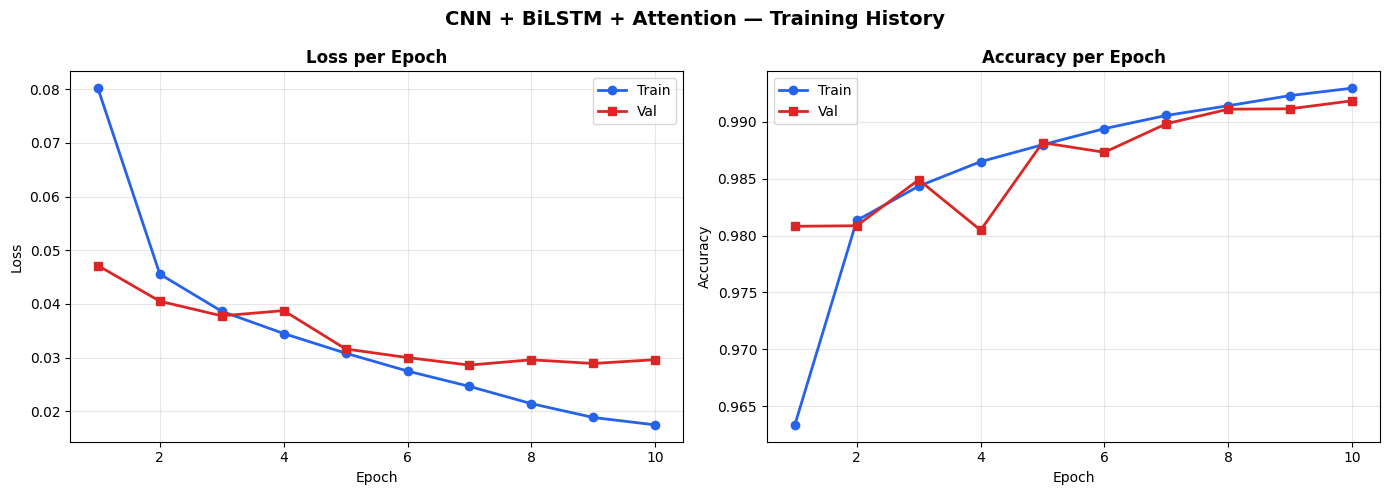


  FINAL TEST SET EVALUATION

  Accuracy  : 0.9900
  AUC-ROC   : 0.9995
  PR-AUC    : 0.9966

              precision    recall  f1-score   support

  Legitimate     0.9985    0.9902    0.9943    213285
    Phishing     0.9305    0.9886    0.9587     28340

    accuracy                         0.9900    241625
   macro avg     0.9645    0.9894    0.9765    241625
weighted avg     0.9905    0.9900    0.9901    241625



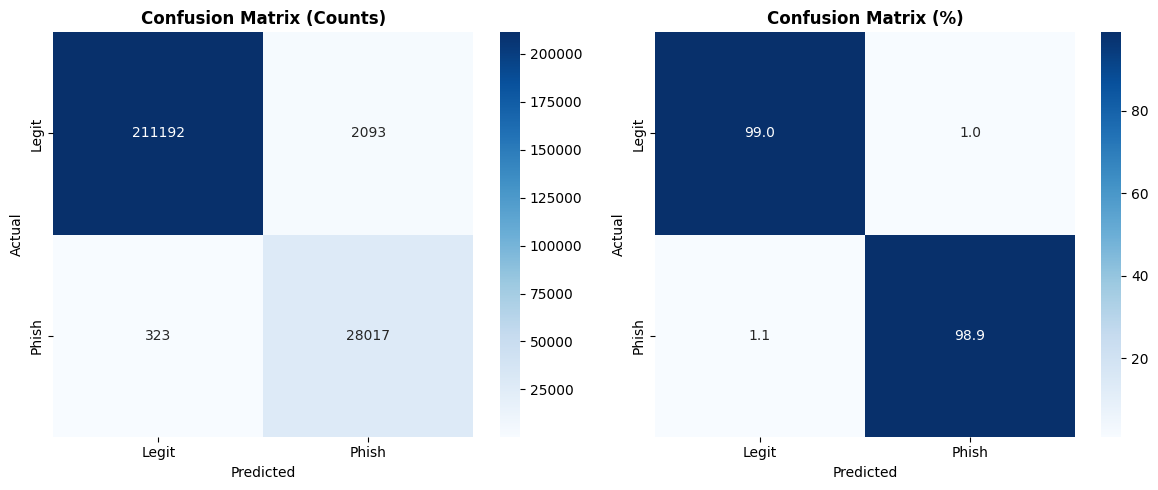

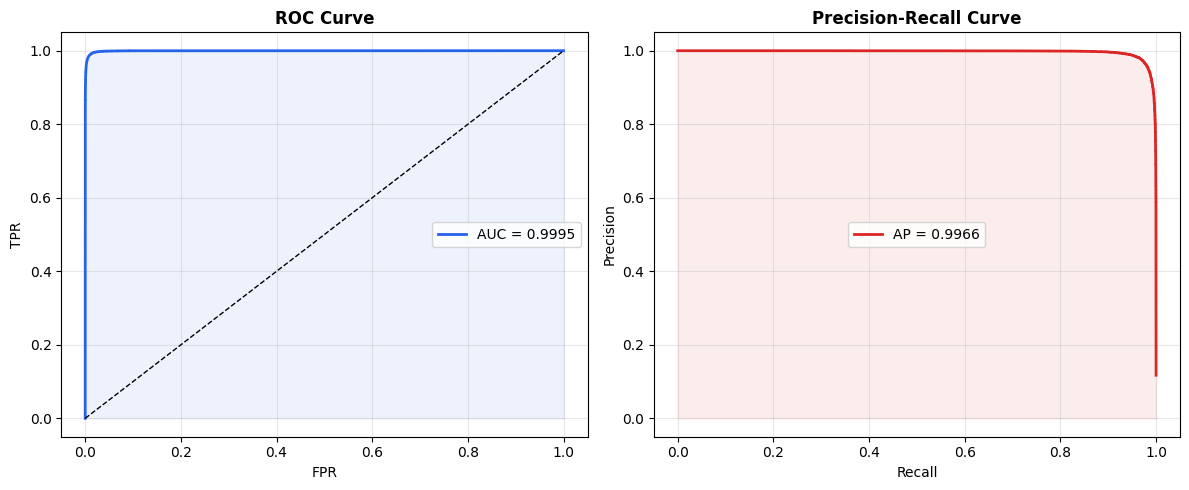


✅ All figures saved!


In [30]:
# ════════════════════════════════════════════════
#  الخلية 11: الرسوم البيانية والتقييم النهائي
# ════════════════════════════════════════════════
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
)

# ── 1. منحنيات التدريب ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(history["train_loss"]) + 1)

axes[0].plot(ep, history["train_loss"], 'o-', label="Train", color="#2563EB", lw=2)
axes[0].plot(ep, history["val_loss"],   's-', label="Val",   color="#DC2626", lw=2)
axes[0].set_title("Loss per Epoch", fontweight='bold')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history["train_acc"], 'o-', label="Train", color="#2563EB", lw=2)
axes[1].plot(ep, history["val_acc"],   's-', label="Val",   color="#DC2626", lw=2)
axes[1].set_title("Accuracy per Epoch", fontweight='bold')
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("CNN + BiLSTM + Attention — Training History", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("training_history.png", dpi=150, bbox_inches='tight')
plt.show()

# ── 2. التقييم النهائي على Test Set ───────────
print("\n" + "="*55)
print("  FINAL TEST SET EVALUATION")
print("="*55)

checkpoint = torch.load(best_model_path, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])

test_m   = evaluate(model, test_loader, criterion, DEVICE)
labels_a = test_m["labels"]
preds_a  = test_m["preds"]
probs_a  = test_m["probs"]

auc_roc = roc_auc_score(labels_a, probs_a)
auc_pr  = average_precision_score(labels_a, probs_a)

print(f"\n  Accuracy  : {test_m['acc']:.4f}")
print(f"  AUC-ROC   : {auc_roc:.4f}")
print(f"  PR-AUC    : {auc_pr:.4f}")
print()
print(classification_report(labels_a, preds_a,
      target_names=["Legitimate","Phishing"], digits=4))

# ── 3. Confusion Matrix ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm = confusion_matrix(labels_a, preds_a)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Legit','Phish'], yticklabels=['Legit','Phish'])
axes[0].set_title("Confusion Matrix (Counts)", fontweight='bold')
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            xticklabels=['Legit','Phish'], yticklabels=['Legit','Phish'])
axes[1].set_title("Confusion Matrix (%)", fontweight='bold')
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# ── 4. ROC و Precision-Recall ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(labels_a, probs_a)
axes[0].plot(fpr, tpr, color="#2563EB", lw=2, label=f"AUC = {auc_roc:.4f}")
axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].fill_between(fpr, tpr, alpha=0.08, color="#2563EB")
axes[0].set_title("ROC Curve", fontweight='bold')
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].legend(); axes[0].grid(alpha=0.3)

prec, rec, _ = precision_recall_curve(labels_a, probs_a)
axes[1].plot(rec, prec, color="#DC2626", lw=2, label=f"AP = {auc_pr:.4f}")
axes[1].fill_between(rec, prec, alpha=0.08, color="#DC2626")
axes[1].set_title("Precision-Recall Curve", fontweight='bold')
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("roc_pr_curves.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ All figures saved!")

In [31]:
# ════════════════════════════════════════════════
#  الخلية 12: اختبار يدوي + حفظ/تحميل الملفات
# ════════════════════════════════════════════════

import os
import torch

def url_to_indices(url, vocab, max_len):
    pad = vocab.get("<PAD>", 0)
    unk = vocab.get("<UNK>", pad)

    if not isinstance(url, str):
        url = str(url)

    url = url[:max_len]
    indices = [vocab.get(ch, unk) for ch in url]

    if len(indices) < max_len:
        indices += [pad] * (max_len - len(indices))

    return indices

def predict_url(url, model, vocab, device):
    model.eval()
    with torch.no_grad():
        idx = url_to_indices(url, vocab, MAX_URL_LEN)
        x = torch.tensor([idx], dtype=torch.long).to(device)
        logits, _ = model(x)
        probs = torch.softmax(logits, dim=1)[0]
        pred = probs.argmax().item()

    return {
        "prediction": "🔴 Phishing" if pred == 1 else "🟢 Legitimate",
        "confidence": f"{probs.max().item() * 100:.2f}%",
        "phish_prob": f"{probs[1].item() * 100:.2f}%"
    }

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(DEVICE)

print(f"🚀 Running on device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"✅ GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ GPU غير متوفر، سيتم التشغيل على CPU")

print("\n🧪 Sample Predictions:\n")

test_urls = [
    ("🟢 يجب أن يكون شرعياً", "https://www.google.com"),
    ("🟢 يجب أن يكون شرعياً", "https://www.github.com/user/repo"),
    ("🔴 يجب أن يكون تصيداً", "http://paypal-verify-login.secure.com/update.php"),
    ("🔴 يجب أن يكون تصيداً", "https://halifax.login-online-auth-verify.com/Login.php"),
    ("🔴 يجب أن يكون تصيداً", "http://192.168.1.1/bank-login?redirect=paypal.com"),
]

for expected, url in test_urls:
    r = predict_url(url, model, vocab, DEVICE)
    match = "✅" if expected[0] == r["prediction"][0] else "❌"
    print(f"{match} Expected: {expected}")
    print(f"   Got      : {r['prediction']} (conf={r['confidence']}, phish_prob={r['phish_prob']})")
    print(f"   URL      : {url}\n")

print("\n📁 Output files:")
output_files = [
    "best_phishing_model.pt",
    "training_history.png",
    "confusion_matrix.png",
    "roc_pr_curves.png"
]

for f in output_files:
    if os.path.exists(f):
        print(f"   ✅ Found: {os.path.abspath(f)}")
    else:
        print(f"   ⚠️ Not found: {f}")

try:
    from google.colab import files
    print("\n📥 Downloading files from Colab...")
    for f in output_files:
        if os.path.exists(f):
            files.download(f)
            print(f"   ✅ Downloaded: {f}")
        else:
            print(f"   ⚠️ File missing: {f}")
except ImportError:
    print("\nℹ️ Not running in Google Colab. Files are saved locally only.")

🚀 Running on device: cuda
✅ GPU Name: NVIDIA RTX 4000 Ada Generation

🧪 Sample Predictions:

✅ Expected: 🟢 يجب أن يكون شرعياً
   Got      : 🟢 Legitimate (conf=58.77%, phish_prob=41.23%)
   URL      : https://www.google.com

✅ Expected: 🟢 يجب أن يكون شرعياً
   Got      : 🟢 Legitimate (conf=76.94%, phish_prob=23.06%)
   URL      : https://www.github.com/user/repo

✅ Expected: 🔴 يجب أن يكون تصيداً
   Got      : 🔴 Phishing (conf=100.00%, phish_prob=100.00%)
   URL      : http://paypal-verify-login.secure.com/update.php

✅ Expected: 🔴 يجب أن يكون تصيداً
   Got      : 🔴 Phishing (conf=100.00%, phish_prob=100.00%)
   URL      : https://halifax.login-online-auth-verify.com/Login.php

✅ Expected: 🔴 يجب أن يكون تصيداً
   Got      : 🔴 Phishing (conf=100.00%, phish_prob=100.00%)
   URL      : http://192.168.1.1/bank-login?redirect=paypal.com


📁 Output files:
   ✅ Found: C:\Users\user\Pdishing_Detection\best_phishing_model.pt
   ✅ Found: C:\Users\user\Pdishing_Detection\training_history.png
   ✅ F

In [32]:
full_df = df.copy()
print(f"✅ full_df ready — {len(full_df):,} rows")
print(f"   Columns: {full_df.columns.tolist()}")
print(f"   Label distribution:\n{full_df['label'].value_counts()}")

✅ full_df ready — 2,416,245 rows
   Columns: ['url', 'label']
   Label distribution:
label
0    2132847
1     283398
Name: count, dtype: int64


In [33]:
# ════════════════════════════════════════════════
#  Helper: stratified_split
# ════════════════════════════════════════════════

import pandas as pd
from sklearn.model_selection import train_test_split

def stratified_split(df, seed=42, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1):
    """
    Split df into train/val/test with class stratification.
    Expects columns: 'url', 'label'
    Returns: train_df, val_df, test_df
    """
    total = train_ratio + val_ratio + test_ratio
    if abs(total - 1.0) > 1e-8:
        raise ValueError(f"Ratios must sum to 1.0, got {total}")

    if "url" not in df.columns or "label" not in df.columns:
        raise ValueError("df must contain 'url' and 'label' columns")

    urls = df["url"].astype(str).tolist()
    labels = pd.to_numeric(df["label"], errors="raise").astype(int).tolist()

    # Step 1: train+val vs test
    urls_tv, urls_test, labs_tv, labs_test = train_test_split(
        urls,
        labels,
        test_size=test_ratio,
        random_state=seed,
        stratify=labels
    )

    # Step 2: train vs val
    val_size_adjusted = val_ratio / (train_ratio + val_ratio)

    urls_train, urls_val, labs_train, labs_val = train_test_split(
        urls_tv,
        labs_tv,
        test_size=val_size_adjusted,
        random_state=seed,
        stratify=labs_tv
    )

    train_df = pd.DataFrame({"url": urls_train, "label": labs_train})
    val_df   = pd.DataFrame({"url": urls_val,   "label": labs_val})
    test_df  = pd.DataFrame({"url": urls_test,  "label": labs_test})

    return train_df, val_df, test_df

print("✅ stratified_split defined")

✅ stratified_split defined


In [34]:
import time
import torch
import numpy as np
import pandas as pd
import random

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

seeds   = [42, 123, 7]
results = []

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

assert 'full_df' in globals(), "❌ شغّل: full_df = df.copy() أولاً"
print(f"✅ full_df confirmed — {len(full_df):,} rows\n")

overall_start = time.time()

for seed in seeds:
    seed_start = time.time()
    print(f"\n{'='*60}")
    print(f"  Running experiment with seed = {seed}")
    print(f"{'='*60}")

    try:
        # 1. ضبط العشوائية
        set_seed(seed)
        print(f"  ✅ set_seed({seed}) done")

        # 2. تقسيم البيانات
        train_df, val_df, test_df = stratified_split(full_df, seed=seed)
        print(f"  ✅ Split — train={len(train_df):,}  val={len(val_df):,}  test={len(test_df):,}")

        # 3. بناء المفردات من training فقط
        vocab = build_vocab(train_df['url'].tolist(), max_chars=MAX_URL_LEN)
        print(f"  ✅ Vocab — size={len(vocab)}")

        # 4. إنشاء DataLoaders
        train_loader, val_loader, test_loader = create_dataloaders(
            train_df['url'].tolist(),  train_df['label'].tolist(),
            val_df['url'].tolist(),    val_df['label'].tolist(),
            test_df['url'].tolist(),   test_df['label'].tolist(),
            vocab
        )
        print(f"  ✅ DataLoaders ready")

        # 5. بناء النموذج
        model = PhishingDetector(vocab_size=len(vocab)).to(DEVICE)
        n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  ✅ Model — {n_params:,} parameters")

        # 6. Class weights
        n_legit = (train_df['label'] == 0).sum()
        n_phish = (train_df['label'] == 1).sum()
        w_legit = len(train_df) / (2.0 * n_legit)
        w_phish = len(train_df) / (2.0 * n_phish)
        class_weights = torch.tensor([w_legit, w_phish], dtype=torch.float).to(DEVICE)
        print(f"  ✅ Weights — w0={w_legit:.4f}  w1={w_phish:.4f}")

        # 7. Loss / Optimizer / Scheduler
        criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr           = LEARNING_RATE,
            weight_decay = WEIGHT_DECAY
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max   = EPOCHS,
            eta_min = 1e-5
        )
        scaler = torch.amp.GradScaler('cuda') if DEVICE.type == "cuda" else None
        print(f"  ✅ Optimizer / Scheduler ready")

        # 8. حلقة التدريب مع Early Stopping
        print(f"\n  🏋️  Training started ...")
        best_val_auc   = 0.0
        best_val_loss  = float('inf')
        patience_count = 0
        PATIENCE       = 5
        best_model_state = None

        for epoch in range(1, EPOCHS + 1):
            # تدريب epoch واحد
            train_m = train_one_epoch(
                model     = model,
                loader    = train_loader,
                optimizer = optimizer,
                criterion = criterion,
                device    = DEVICE,
                scaler    = scaler
            )

            # تقييم على validation
            val_m = evaluate(
                model     = model,
                loader    = val_loader,
                criterion = criterion,
                device    = DEVICE
            )

            # تحديث scheduler
            scheduler.step()

            print(
                f"  Epoch {epoch:02d}/{EPOCHS} | "
                f"train_loss={train_m['loss']:.4f} | "
                f"val_loss={val_m['loss']:.4f} | "
                f"val_f1={val_m['f1']:.4f} | "
                f"val_auc={val_m['auc']:.4f}"
            )

            # Early Stopping بناءً على val_auc
            if val_m['auc'] > best_val_auc:
                best_val_auc     = val_m['auc']
                best_val_loss    = val_m['loss']
                patience_count   = 0
                best_model_state = {
                    k: v.cpu().clone() for k, v in model.state_dict().items()
                }
                print(f"  ✅ New best val_auc={best_val_auc:.4f} — checkpoint saved")
            else:
                patience_count += 1
                print(f"  ⏳ No improvement — patience {patience_count}/{PATIENCE}")
                if patience_count >= PATIENCE:
                    print(f"  🛑 Early stopping at epoch {epoch}")
                    break

        # استعادة أفضل نموذج
        if best_model_state is not None:
            model.load_state_dict(
                {k: v.to(DEVICE) for k, v in best_model_state.items()}
            )
            print(f"  ✅ Best model restored — val_auc={best_val_auc:.4f}")

        # 9. التقييم على test set
        print(f"\n  📊 Evaluating on test set ...")
        test_m = evaluate(
            model     = model,
            loader    = test_loader,
            criterion = criterion,
            device    = DEVICE
        )
        print(f"  ✅ Evaluation complete")

        # 10. تسجيل النتائج
        seed_time = time.time() - seed_start
        results.append({
            "seed"    : seed,
            "accuracy": test_m["acc"],
            "f1"      : test_m["f1"],
            "auc"     : test_m["auc"],
            "pr_auc"  : float(average_precision_score(
                            test_m["labels"], test_m["probs"])),
            "time_sec": seed_time
        })

        print(
            f"\n  📌 Seed {seed}: "
            f"Acc={test_m['acc']:.4f} | "
            f"F1={test_m['f1']:.4f} | "
            f"AUC={test_m['auc']:.4f} | "
            f"PR-AUC={results[-1]['pr_auc']:.4f} | "
            f"Time={seed_time/60:.2f} min"
        )

        # تحرير الذاكرة
        del model, train_loader, val_loader, test_loader, best_model_state
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        print(f"  🧹 GPU memory cleared")

    except Exception as e:
        import traceback
        print(f"\n  ❌ Seed {seed} FAILED")
        print(f"  Error: {e}")
        traceback.print_exc()
        print(f"  ⚠️  Skipping to next seed...\n")
        continue

# ── النتائج النهائية ──────────────────────────────────────
total_time = time.time() - overall_start

if len(results) == 0:
    print("\n❌ No results — check errors above")
else:
    results_df = pd.DataFrame(results)

    summary_df = pd.DataFrame({
        "metric": ["accuracy", "f1", "auc", "pr_auc"],
        "mean"  : [
            results_df["accuracy"].mean(),
            results_df["f1"].mean(),
            results_df["auc"].mean(),
            results_df["pr_auc"].mean()
        ],
        "std"   : [
            results_df["accuracy"].std(ddof=0),
            results_df["f1"].std(ddof=0),
            results_df["auc"].std(ddof=0),
            results_df["pr_auc"].std(ddof=0)
        ]
    })

    summary_df["mean±std"] = summary_df.apply(
        lambda row: f"{row['mean']:.4f} ± {row['std']:.4f}", axis=1
    )

    print("\n" + "="*60)
    print("  FINAL RESULTS")
    print("="*60)

    print("\n📋 Per-seed results:")
    print(results_df[["seed","accuracy","f1","auc","pr_auc","time_sec"]].to_string(index=False))

    print("\n📊 Summary (mean ± std across 3 seeds):")
    print(summary_df[["metric","mean±std"]].to_string(index=False))

    print(f"\n⏱️  Total runtime: {total_time/60:.2f} min")

    results_df.to_csv("multiseed_per_seed.csv", index=False)
    summary_df.to_csv("multiseed_summary.csv",  index=False)
    print("\n💾 Saved: multiseed_per_seed.csv  |  multiseed_summary.csv")

Using device: cuda
GPU: NVIDIA RTX 4000 Ada Generation
✅ full_df confirmed — 2,416,245 rows


  Running experiment with seed = 42
  ✅ set_seed(42) done
  ✅ Split — train=1,932,995  val=241,625  test=241,625
  ✅ Vocab — size=420
  ✅ DataLoaders ready
  ✅ Model — 901,699 parameters
  ✅ Weights — w0=0.5664  w1=4.2630
  ✅ Optimizer / Scheduler ready

  🏋️  Training started ...
  Epoch 01/10 | train_loss=0.0766 | val_loss=0.0488 | val_f1=0.9069 | val_auc=0.9984
  ✅ New best val_auc=0.9984 — checkpoint saved
  Epoch 02/10 | train_loss=0.0444 | val_loss=0.0399 | val_f1=0.9263 | val_auc=0.9990
  ✅ New best val_auc=0.9990 — checkpoint saved
  Epoch 03/10 | train_loss=0.0374 | val_loss=0.0356 | val_f1=0.9479 | val_auc=0.9992
  ✅ New best val_auc=0.9992 — checkpoint saved
  Epoch 04/10 | train_loss=0.0333 | val_loss=0.0333 | val_f1=0.9555 | val_auc=0.9993
  ✅ New best val_auc=0.9993 — checkpoint saved
  Epoch 05/10 | train_loss=0.0298 | val_loss=0.0310 | val_f1=0.9520 | val_auc=0.9994
  ✅ New bes

In [35]:
import subprocess
result = subprocess.run(
    ["pip", "install", "transformers", "accelerate", "-q"],
    capture_output=True, text=True
)
print(result.stdout[-500:] if result.stdout else "")
print(result.stderr[-300:] if result.stderr else "")
print("✅ Installation complete" if result.returncode == 0 else f"❌ Failed: {result.returncode}")



✅ Installation complete


In [36]:
import transformers
import torch
print(f"transformers: {transformers.__version__}")
print(f"torch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    total    = torch.cuda.get_device_properties(0).total_memory / 1024**3
    reserved = torch.cuda.memory_reserved(0) / 1024**3
    free     = total - reserved
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: total={total:.1f}GB | reserved={reserved:.1f}GB | free={free:.1f}GB")

try:
    from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
    print("✅ DistilBert imports OK")
except ImportError as e:
    print(f"❌ {e}")

C:\Users\user\anaconda3\envs\phishing_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


transformers: 5.5.4
torch: 2.7.1+cu118
CUDA: True
GPU: NVIDIA RTX 4000 Ada Generation
Memory: total=20.0GB | reserved=0.1GB | free=19.9GB
✅ DistilBert imports OK


In [1]:
# ════════════════════════════════════════════════
#  خلية مستقلة: حفظ كل النتائج بعد انتهاء التدريب
# ════════════════════════════════════════════════

import os
import json
import torch
import pandas as pd
from datetime import datetime

SAVE_DIR = "saved_results"
os.makedirs(SAVE_DIR, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

print("💾 Saving all available results...")

# 1) حفظ history إذا موجود
if "history" in globals():
    history_path = os.path.join(SAVE_DIR, f"history_{timestamp}.json")
    with open(history_path, "w", encoding="utf-8") as f:
        json.dump(history, f, ensure_ascii=False, indent=2)
    print(f"✅ History saved: {history_path}")
else:
    print("⚠️ history not found")

# 2) حفظ أفضل نموذج إذا موجود
if "model" in globals():
    model_path = os.path.join(SAVE_DIR, f"final_model_state_{timestamp}.pt")
    torch.save(model.state_dict(), model_path)
    print(f"✅ Model state_dict saved: {model_path}")
else:
    print("⚠️ model not found")

# 3) حفظ checkpoint كامل إذا العناصر موجودة
checkpoint_items = (
    "model" in globals() and
    "optimizer" in globals() and
    "scheduler" in globals()
)

if checkpoint_items:
    checkpoint_path = os.path.join(SAVE_DIR, f"checkpoint_{timestamp}.pt")
    torch.save({
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "vocab": vocab if "vocab" in globals() else None,
        "history": history if "history" in globals() else None,
    }, checkpoint_path)
    print(f"✅ Checkpoint saved: {checkpoint_path}")
else:
    print("⚠️ Full checkpoint not saved (model/optimizer/scheduler missing)")

# 4) حفظ نتائج test إذا موجودة
if "test_m" in globals():
    metrics_dict = {}
    for k, v in test_m.items():
        if isinstance(v, (int, float, str)):
            metrics_dict[k] = v
        elif hasattr(v, "tolist"):
            # لا نحفظ arrays الضخمة هنا إلا إذا أردت
            pass

    metrics_path = os.path.join(SAVE_DIR, f"test_metrics_{timestamp}.json")
    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(metrics_dict, f, ensure_ascii=False, indent=2)
    print(f"✅ Test metrics saved: {metrics_path}")
else:
    print("⚠️ test_m not found")

# 5) حفظ المقارنة إذا موجودة
if "comparison" in globals():
    comparison_path = os.path.join(SAVE_DIR, f"comparison_{timestamp}.csv")
    comparison.to_csv(comparison_path, index=False)
    print(f"✅ Comparison table saved: {comparison_path}")
else:
    print("⚠️ comparison not found")

# 6) حفظ ملخص نصي سريع
summary_path = os.path.join(SAVE_DIR, f"summary_{timestamp}.txt")
with open(summary_path, "w", encoding="utf-8") as f:
    f.write("Saved training artifacts\n")
    f.write(f"Timestamp: {timestamp}\n\n")

    if "test_m" in globals():
        f.write("Test Metrics:\n")
        for k, v in test_m.items():
            if isinstance(v, (int, float, str)):
                f.write(f"{k}: {v}\n")

    if "history" in globals():
        f.write("\nHistory keys:\n")
        for k in history.keys():
            f.write(f"- {k}\n")

print(f"✅ Summary saved: {summary_path}")

# 7) عرض الملفات المحفوظة
print("\n📁 Saved files:")
for file_name in os.listdir(SAVE_DIR):
    print(" -", os.path.abspath(os.path.join(SAVE_DIR, file_name)))

💾 Saving all available results...
⚠️ history not found
⚠️ model not found
⚠️ Full checkpoint not saved (model/optimizer/scheduler missing)
⚠️ test_m not found
⚠️ comparison not found
✅ Summary saved: saved_results\summary_20260420_034505.txt

📁 Saved files:
 - C:\Users\user\Pdishing_Detection\saved_results\summary_20260420_034505.txt


In [2]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_path = r"C:\Users\user\Pdishing_Detection\best_phishing_model.pt"
checkpoint = torch.load(checkpoint_path, map_location=DEVICE)

print("✅ Checkpoint loaded")

✅ Checkpoint loaded


In [8]:
# اكتشاف مسار الـ notebook الحالي
import os
import sys

print(f"Working directory: {os.getcwd()}")
print(f"\nFiles in current directory:")
for f in os.listdir('.'):
    if f.endswith('.ipynb') or f.endswith('.py') or f.endswith('.csv'):
        size = os.path.getsize(f) / 1024**2
        print(f"  {f} ({size:.1f} MB)")

Working directory: C:\Users\user\Pdishing_Detection

Files in current directory:
  Goal1_phishing_detection.ipynb (0.3 MB)
  multiseed_per_seed.csv (0.0 MB)
  multiseed_summary.csv (0.0 MB)
  phishing_dataset_final.csv (80.7 MB)
  Untitled.ipynb (0.0 MB)


In [9]:
import pandas as pd

print("📥 Loading dataset...")
df = pd.read_csv(r"C:\Users\user\Pdishing_Detection\phishing_dataset_final.csv")
print(f"✅ df loaded — {len(df):,} rows")
print(f"   Columns: {df.columns.tolist()}")
print(f"   Label dist:\n{df['label'].value_counts()}")

full_df = df.copy()
print(f"\n✅ full_df ready — {len(full_df):,} rows")

📥 Loading dataset...
✅ df loaded — 2,416,245 rows
   Columns: ['url', 'label']
   Label dist:
label
0    2132847
1     283398
Name: count, dtype: int64

✅ full_df ready — 2,416,245 rows


In [10]:
# تعريف stratified_split إذا لم تكن موجودة
from sklearn.model_selection import train_test_split

def stratified_split(df, seed=42):
    train_df, temp_df = train_test_split(
        df, test_size=0.2,
        stratify=df['label'],
        random_state=seed
    )
    val_df, test_df = train_test_split(
        temp_df, test_size=0.5,
        stratify=temp_df['label'],
        random_state=seed
    )
    return train_df.reset_index(drop=True), \
           val_df.reset_index(drop=True), \
           test_df.reset_index(drop=True)

print("✅ stratified_split defined")

✅ stratified_split defined


In [11]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import gc
import time
import torch
import numpy as np
import pandas as pd
import random
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from sklearn.metrics import (f1_score, roc_auc_score,
                             average_precision_score, accuracy_score)

# ── إعدادات آمنة مضمونة ───────────────────────────────────
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BERT_MODEL    = "distilbert-base-uncased"
MAX_LEN       = 64       # مخفض لتوفير الذاكرة
BERT_EPOCHS   = 3
BERT_BATCH    = 32       # صغير جداً لضمان الاستقرار
BERT_LR       = 2e-5
BERT_PATIENCE = 2
BERT_SEED     = 42

# ── حجم العينة الآمن ──────────────────────────────────────
SAMPLE_TRAIN  = 20_000
SAMPLE_VAL    =  2_500
SAMPLE_TEST   =  2_500

print(f"Device      : {DEVICE}")
print(f"GPU         : {torch.cuda.get_device_name(0)}")
print(f"MAX_LEN     : {MAX_LEN}")
print(f"BATCH       : {BERT_BATCH}")
print(f"Sample train: {SAMPLE_TRAIN:,}")

# تحقق من الذاكرة
import psutil
ram = psutil.virtual_memory()
vram_total = torch.cuda.get_device_properties(0).total_memory / 1024**3
vram_free  = (torch.cuda.get_device_properties(0).total_memory
              - torch.cuda.memory_reserved(0)) / 1024**3
print(f"RAM free    : {ram.available/1024**3:.1f} GB")
print(f"VRAM free   : {vram_free:.1f} GB")

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(BERT_SEED)
print(f"✅ Ready\n")

# ── تجهيز البيانات ────────────────────────────────────────
assert 'full_df' in globals(), "❌ شغّل full_df = df.copy() أولاً"
print(f"📥 Preparing data sample ...")

train_df, val_df, test_df = stratified_split(full_df, seed=BERT_SEED)

def safe_sample(df, n, seed):
    """أخذ عينة مع الحفاظ على نسبة الفئات"""
    return df.groupby('label', group_keys=False).apply(
        lambda x: x.sample(
            min(int(n * len(x) / len(df)), len(x)),
            random_state=seed
        )
    ).reset_index(drop=True)

train_s = safe_sample(train_df, SAMPLE_TRAIN, BERT_SEED)
val_s   = safe_sample(val_df,   SAMPLE_VAL,   BERT_SEED)
test_s  = safe_sample(test_df,  SAMPLE_TEST,  BERT_SEED)

print(f"✅ train={len(train_s):,} | val={len(val_s):,} | test={len(test_s):,}")
print(f"   Phishing ratio — train: {train_s['label'].mean()*100:.1f}%")

# تحرير الذاكرة فوراً
del train_df, val_df, test_df
gc.collect()
print(f"✅ Memory freed")

# ── Tokenization ──────────────────────────────────────────
print(f"\n📥 Loading tokenizer ...")
tokenizer = DistilBertTokenizer.from_pretrained(BERT_MODEL)
print(f"✅ Tokenizer ready")

print(f"⏳ Tokenizing {SAMPLE_TRAIN+SAMPLE_VAL+SAMPLE_TEST:,} URLs ...")
tok_start = time.time()

def tokenize(urls, tokenizer, max_len):
    return tokenizer(
        list(urls),
        max_length     = max_len,
        truncation     = True,
        padding        = "max_length",
        return_tensors = "pt"
    )

train_enc = tokenize(train_s['url'], tokenizer, MAX_LEN)
val_enc   = tokenize(val_s['url'],   tokenizer, MAX_LEN)
test_enc  = tokenize(test_s['url'],  tokenizer, MAX_LEN)
print(f"✅ Tokenized in {(time.time()-tok_start):.1f} sec")

# ── Dataset ───────────────────────────────────────────────
class EncodedDataset(Dataset):
    def __init__(self, encodings, labels):
        self.ids   = encodings["input_ids"]
        self.masks = encodings["attention_mask"]
        self.labs  = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labs)

    def __getitem__(self, idx):
        return {
            "input_ids"     : self.ids[idx],
            "attention_mask": self.masks[idx],
            "labels"        : self.labs[idx]
        }

train_ds = EncodedDataset(train_enc, train_s['label'].tolist())
val_ds   = EncodedDataset(val_enc,   val_s['label'].tolist())
test_ds  = EncodedDataset(test_enc,  test_s['label'].tolist())

# تحرير encodings من الذاكرة
del train_enc, val_enc, test_enc
gc.collect()

# ── DataLoaders — num_workers=0 إلزامي على Windows ────────
train_loader = DataLoader(train_ds, batch_size=BERT_BATCH,
                          shuffle=True,  num_workers=0,
                          pin_memory=False)  # False لتوفير الذاكرة
val_loader   = DataLoader(val_ds,   batch_size=BERT_BATCH,
                          shuffle=False, num_workers=0,
                          pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BERT_BATCH,
                          shuffle=False, num_workers=0,
                          pin_memory=False)
print(f"✅ DataLoaders ready — num_workers=0 | pin_memory=False")

# ── النموذج ───────────────────────────────────────────────
print(f"\n📥 Loading DistilBERT ...")
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()

bert_model = DistilBertForSequenceClassification.from_pretrained(
    BERT_MODEL, num_labels=2
).to(DEVICE)

n_params = sum(p.numel() for p in bert_model.parameters())
vram_used = torch.cuda.memory_allocated(0) / 1024**3
print(f"✅ Model — {n_params:,} params | VRAM used: {vram_used:.2f} GB")

# ── Class Weights ─────────────────────────────────────────
n0 = (train_s['label'] == 0).sum()
n1 = (train_s['label'] == 1).sum()
w0 = len(train_s) / (2.0 * n0)
w1 = len(train_s) / (2.0 * n1)
weights   = torch.tensor([w0, w1], dtype=torch.float).to(DEVICE)
criterion = torch.nn.CrossEntropyLoss(weight=weights)
print(f"✅ Weights — w0={w0:.4f} | w1={w1:.4f}")

# ── Optimizer ─────────────────────────────────────────────
optimizer   = torch.optim.AdamW(
    bert_model.parameters(), lr=BERT_LR, weight_decay=1e-4
)
scaler      = torch.amp.GradScaler('cuda')
total_steps = len(train_loader) * BERT_EPOCHS
scheduler   = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=1.0,
    end_factor=0.0, total_iters=total_steps
)
print(f"✅ Optimizer — total_steps={total_steps:,}")

# ── دوال التدريب والتقييم ─────────────────────────────────
def bert_train_epoch(model, loader, optimizer,
                     criterion, device, scaler, scheduler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    n_batches = len(loader)

    for i, batch in enumerate(loader):
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labs = batch["labels"].to(device)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            out  = model(input_ids=ids, attention_mask=mask)
            loss = criterion(out.logits, labs)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        preds       = out.logits.argmax(dim=1)
        total_loss += loss.item() * labs.size(0)
        correct    += (preds == labs).sum().item()
        total      += labs.size(0)

        # طباعة كل 100 batch
        if (i + 1) % 100 == 0 or (i + 1) == n_batches:
            print(f"    [{i+1}/{n_batches}] "
                  f"loss={total_loss/total:.4f} "
                  f"acc={correct/total:.4f}",
                  flush=True)

    return {"loss": total_loss/total, "acc": correct/total}


def bert_evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in loader:
            ids  = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            labs = batch["labels"].to(device)

            with torch.amp.autocast('cuda'):
                out  = model(input_ids=ids, attention_mask=mask)
                loss = criterion(out.logits, labs)

            probs = torch.softmax(out.logits, dim=1)[:, 1]
            preds = out.logits.argmax(dim=1)

            total_loss += loss.item() * labs.size(0)
            all_preds  .extend(preds.cpu().numpy())
            all_labels .extend(labs.cpu().numpy())
            all_probs  .extend(probs.cpu().numpy())

    p = np.array(all_preds)
    l = np.array(all_labels)
    r = np.array(all_probs)

    return {
        "loss"  : total_loss / len(l),
        "acc"   : accuracy_score(l, p),
        "f1"    : f1_score(l, p, pos_label=1, average='binary'),
        "auc"   : roc_auc_score(l, r),
        "pr_auc": average_precision_score(l, r),
    }

# ── حلقة التدريب ──────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  Training DistilBERT")
print(f"  Sample: {SAMPLE_TRAIN:,} train | batch={BERT_BATCH} | max_len={MAX_LEN}")
print(f"{'='*60}\n")

best_auc       = 0.0
patience_count = 0
best_state     = None
overall_start  = time.time()

for epoch in range(1, BERT_EPOCHS + 1):
    t0 = time.time()
    print(f"  Epoch {epoch}/{BERT_EPOCHS} starting ...", flush=True)

    tr = bert_train_epoch(
        bert_model, train_loader, optimizer,
        criterion, DEVICE, scaler, scheduler
    )
    va = bert_evaluate(bert_model, val_loader, criterion, DEVICE)

    epoch_time = time.time() - t0
    print(
        f"\n  Epoch {epoch:02d} done | "
        f"train_loss={tr['loss']:.4f} | "
        f"val_loss={va['loss']:.4f} | "
        f"val_f1={va['f1']:.4f} | "
        f"val_auc={va['auc']:.4f} | "
        f"time={epoch_time/60:.1f} min",
        flush=True
    )

    if va['auc'] > best_auc:
        best_auc       = va['auc']
        patience_count = 0
        best_state     = {
            k: v.cpu().clone()
            for k, v in bert_model.state_dict().items()
        }
        print(f"  ✅ Best saved — val_auc={best_auc:.4f}", flush=True)
    else:
        patience_count += 1
        print(f"  ⏳ Patience {patience_count}/{BERT_PATIENCE}", flush=True)
        if patience_count >= BERT_PATIENCE:
            print(f"  🛑 Early stop at epoch {epoch}", flush=True)
            break

# ── تقييم Test ────────────────────────────────────────────
if best_state:
    bert_model.load_state_dict(
        {k: v.to(DEVICE) for k, v in best_state.items()}
    )
    print(f"\n✅ Best model restored")

print(f"\n📊 Evaluating test set ...", flush=True)
te         = bert_evaluate(bert_model, test_loader, criterion, DEVICE)
total_time = time.time() - overall_start

# ── النتائج النهائية ──────────────────────────────────────
print(f"\n{'='*60}")
print(f"  DistilBERT RESULTS")
print(f"  (20K training sample | max_len=64 | batch=32)")
print(f"{'='*60}")
print(f"  Accuracy : {te['acc']*100:.2f}%")
print(f"  F1       : {te['f1']:.4f}")
print(f"  AUC-ROC  : {te['auc']:.4f}")
print(f"  PR-AUC   : {te['pr_auc']:.4f}")
print(f"  Params   : {n_params:,}")
print(f"  Time     : {total_time/60:.1f} min")

# ── جدول المقارنة ─────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  COMPARISON TABLE")
print(f"{'='*60}")

comparison = pd.DataFrame({
    "Model"      : ["CNN-BiLSTM-Att (proposed)",
                    "DistilBERT (20K subset)"],
    "Params"     : ["968,259", f"{n_params:,}"],
    "Train size" : ["2,416,245", f"{SAMPLE_TRAIN:,}"],
    "Accuracy"   : ["99.18 ± 0.02%", f"{te['acc']*100:.2f}%"],
    "F1"         : ["0.9658 ± 0.0008", f"{te['f1']:.4f}"],
    "AUC-ROC"    : ["0.9996 ± 0.0000", f"{te['auc']:.4f}"],
    "PR-AUC"     : ["0.9973 ± 0.0001", f"{te['pr_auc']:.4f}"],
    "Latency"    : ["sub-ms", "~10-50ms"],
})

print(comparison.to_string(index=False))
comparison.to_csv("distilbert_comparison.csv", index=False)
print(f"\n💾 Saved: distilbert_comparison.csv")
print(f"⏱️  Total: {total_time/60:.1f} min")

Device      : cuda
GPU         : NVIDIA RTX 4000 Ada Generation
MAX_LEN     : 64
BATCH       : 32
Sample train: 20,000
RAM free    : 40.4 GB
VRAM free   : 20.0 GB
✅ Ready

📥 Preparing data sample ...


C:\Users\user\AppData\Local\Temp\ipykernel_43764\1936067497.py:65: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('label', group_keys=False).apply(
C:\Users\user\AppData\Local\Temp\ipykernel_43764\1936067497.py:65: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('label', group_keys=False).apply(
C:\Users\user\AppData\Local\Temp\ipykernel_43764\1936067497.py:65: FutureWarning: DataFram

✅ train=19,999 | val=2,499 | test=2,499
   Phishing ratio — train: 11.7%
✅ Memory freed

📥 Loading tokenizer ...
✅ Tokenizer ready
⏳ Tokenizing 25,000 URLs ...
✅ Tokenized in 5.0 sec
✅ DataLoaders ready — num_workers=0 | pin_memory=False

📥 Loading DistilBERT ...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2518.77it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model — 66,955,010 params | VRAM used: 0.26 GB
✅ Weights — w0=0.5664 | w1=4.2642
✅ Optimizer — total_steps=1,875

  Training DistilBERT
  Sample: 20,000 train | batch=32 | max_len=64

  Epoch 1/3 starting ...
    [100/625] loss=0.2464 acc=0.8994
    [200/625] loss=0.2003 acc=0.9200
    [300/625] loss=0.1832 acc=0.9319
    [400/625] loss=0.1666 acc=0.9405
    [500/625] loss=0.1557 acc=0.9448
    [600/625] loss=0.1472 acc=0.9487
    [625/625] loss=0.1453 acc=0.9497

  Epoch 01 done | train_loss=0.1453 | val_loss=0.0647 | val_f1=0.9147 | val_auc=0.9950 | time=0.8 min
  ✅ Best saved — val_auc=0.9950
  Epoch 2/3 starting ...
    [100/625] loss=0.0707 acc=0.9809
    [200/625] loss=0.0796 acc=0.9827
    [300/625] loss=0.0803 acc=0.9826
    [400/625] loss=0.0774 acc=0.9824
    [500/625] loss=0.0797 acc=0.9827
    [600/625] loss=0.0779 acc=0.9830
    [625/625] loss=0.0768 acc=0.9831

  Epoch 02 done | train_loss=0.0768 | val_loss=0.0646 | val_f1=0.9251 | val_auc=0.9969 | time=0.7 min
  ✅ Best